In [30]:
# Imports
import polars as pl
from matplotlib import pyplot as plt
%matplotlib inline
import glob

In [31]:
# load experiments
# experiments = {
#     "moderate_load": {
#         "label": "moderate load",
#         "robot_glob": "../timestamp_results/thesis-eval-experiments/moderate-load/robot-states-#1/*.csv",
#         "completed_glob": "../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*completed*.csv",
#         "received_glob": "../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*received*.csv",
#     },
#     "high_load": {
#         "label": "high load",
#         "robot_glob": "../timestamp_results/thesis-eval-experiments/high-load/robot-states-#1/*.csv",
#         "completed_glob": "../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*completed*.csv",
#         "received_glob": "../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*received*.csv",
#     },
# }

# rearrangement experiments
experiments = {
    "worst_case_reference": {
        "label": "worst case reference",
        "robot_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_reference/10_orders/*robot-states-#0.csv",
        "completed_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_reference/10_orders/*completed*.csv",
        "received_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_reference/10_orders/*received*.csv",
    },
    "worst_case_rearrangement": {
        "label": "worst case rearrangement",
        "robot_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_adaptive/10_orders/*robot-states-#0.csv",
        "completed_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_adaptive/10_orders/*completed*.csv",
        "received_glob": "../timestamp_results/thesis-eval-experiments/rearrangement_wc_adaptive/10_orders/*received*.csv",
    },
}

def load_experiment(spec):
    robot_files = glob.glob(spec["robot_glob"])
    completed_file = glob.glob(spec["completed_glob"])[0]
    received_file = glob.glob(spec["received_glob"])[0]

    robot_df = pl.concat([pl.read_csv(file, has_header=True, separator=",") for file in robot_files])
    # Sort by position and timestamp to ensure correct order
    robot_df = robot_df.sort(by=["Position", "Timestamp"])
    completed_df = pl.read_csv(completed_file, has_header=True, separator=",")
    received_df = pl.read_csv(received_file, has_header=True, separator=",")
    return robot_df, completed_df, received_df

loaded = {
    name: load_experiment(spec)
    for name, spec in experiments.items()
}

In [32]:
for name, (robot_df, completed_df, received_df) in loaded.items():
    label = experiments[name]["label"]
    # Get t0 reference timestamp from received order timestamps
    t0_reference = received_df.filter(pl.col("ReceivedOrdersCount") == 1)["Timestamp"][0]
    # Set t0 reference for robots
    robot_df = robot_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    # Set t0 reference for completed orders
    completed_df = completed_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    # Set t0 reference for received orders
    received_df = received_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )

    print(label)
    print(completed_df.select(pl.col("Timestamp").max()).item() / 1e9)

worst case reference
30.002627
worst case rearrangement
27.11316


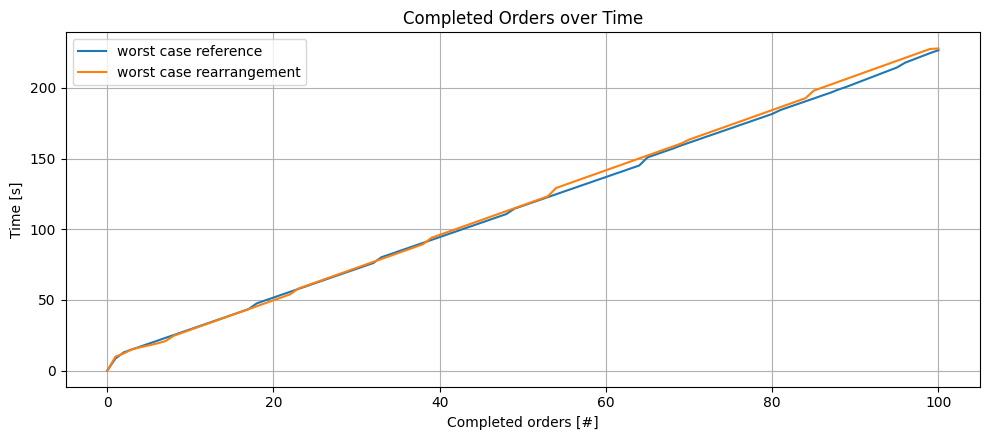

In [26]:
normalized_completed = {}
for name, (robot_df, completed_df, received_df) in loaded.items():
    label = experiments[name]["label"]
    t0 = received_df.filter(pl.col("ReceivedOrdersCount") == 1)["Timestamp"][0]
    completed_norm = completed_df.with_columns(
        pl.when(pl.col("Timestamp") - t0 < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0)
        .alias("Timestamp")
    )
    normalized_completed[name] = (label, completed_norm)

plt.figure(figsize=(10, 4.5))
for name, (label, df) in normalized_completed.items():
    plt.plot(df["CompletedOrdersCount"].to_numpy(), df["Timestamp"].to_numpy() / 1e9, label=label)
plt.xlabel("Completed orders [#]")
plt.ylabel("Time [s]")
plt.title("Completed Orders over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [27]:
for name, (robot_df, completed_df, received_df) in loaded.items():
    label = experiments[name]["label"]
    # Get t0 reference timestamp from received order timestamps
    t0_reference = received_df.filter(pl.col("ReceivedOrdersCount") == 1)["Timestamp"][0]
    # Set t0 reference for completed orders
    completed_df = completed_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    print(f"{label} makespan: {completed_df.select(pl.col('Timestamp').max()).item() / 1e9:.3f} s")
    avg_interval = (
        completed_df.filter(pl.col("Timestamp") > 0)
        .select(pl.col("Timestamp").diff().mean())
        .item()        / 1e9
    )
    print(f"{label} average interval: {avg_interval:.3f} s")

worst case reference makespan: 226.673 s
worst case reference average interval: 2.202 s
worst case rearrangement makespan: 227.908 s
worst case rearrangement average interval: 2.202 s


Average share percentages for worst case reference:
shape: (4, 3)
┌────────────────────┬──────────────┬─────────────────┐
│ STATE_NAME         ┆ DURATION_NS  ┆ AverageSharePct │
│ ---                ┆ ---          ┆ ---             │
│ str                ┆ i64          ┆ f64             │
╞════════════════════╪══════════════╪═════════════════╡
│ IDLING             ┆ 386384685000 ┆ 42.614797       │
│ WAITING_FOR_PICKUP ┆ 78812240000  ┆ 8.69229         │
│ COOKING            ┆ 343384500000 ┆ 37.872259       │
│ RETOOLING          ┆ 98109931000  ┆ 10.820654       │
└────────────────────┴──────────────┴─────────────────┘



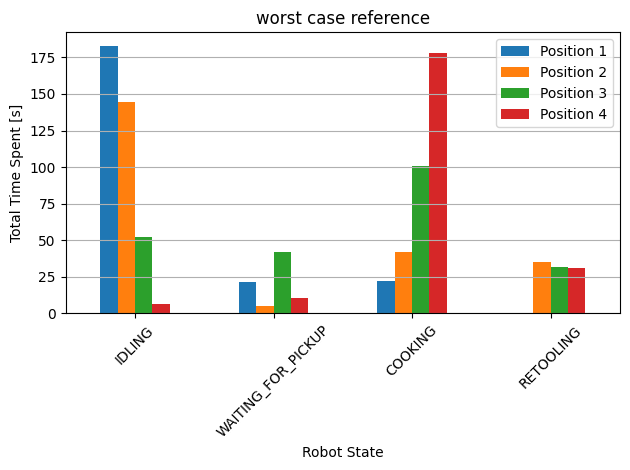

Total time recorded for Position 1: 226.673 seconds
IDLING share for Position 1: 183.001 seconds (80.73%)
COOKING share for Position 1: 22.212 seconds (9.80%)
RETOOLING share for Position 1: 0.000 seconds (0.00%)
WAITING_FOR_PICKUP share for Position 1: 21.459 seconds (9.47%)
REARRANGING share for Position 1: 0.000 seconds (0.00%)
RECONFIGURING share for Position 1: 0.000 seconds (0.00%)

Total time recorded for Position 2: 226.673 seconds
IDLING share for Position 2: 144.640 seconds (63.81%)
COOKING share for Position 2: 42.032 seconds (18.54%)
RETOOLING share for Position 2: 35.239 seconds (15.55%)
WAITING_FOR_PICKUP share for Position 2: 4.762 seconds (2.10%)
REARRANGING share for Position 2: 0.000 seconds (0.00%)
RECONFIGURING share for Position 2: 0.000 seconds (0.00%)

Total time recorded for Position 3: 226.673 seconds
IDLING share for Position 3: 52.168 seconds (23.01%)
COOKING share for Position 3: 101.074 seconds (44.59%)
RETOOLING share for Position 3: 31.513 seconds (13.90%

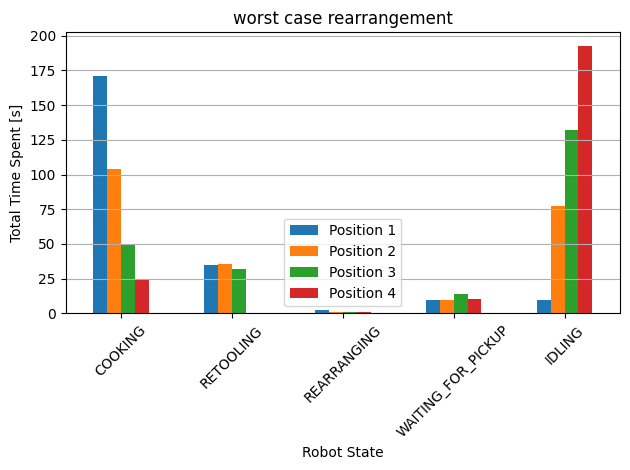

Total time recorded for Position 1: 227.908 seconds
IDLING share for Position 1: 9.672 seconds (4.24%)
COOKING share for Position 1: 171.208 seconds (75.12%)
RETOOLING share for Position 1: 34.986 seconds (15.35%)
WAITING_FOR_PICKUP share for Position 1: 9.804 seconds (4.30%)
REARRANGING share for Position 1: 2.238 seconds (0.98%)
RECONFIGURING share for Position 1: 0.000 seconds (0.00%)

Total time recorded for Position 2: 227.908 seconds
IDLING share for Position 2: 77.330 seconds (33.93%)
COOKING share for Position 2: 103.910 seconds (45.59%)
RETOOLING share for Position 2: 35.618 seconds (15.63%)
WAITING_FOR_PICKUP share for Position 2: 9.949 seconds (4.37%)
REARRANGING share for Position 2: 1.101 seconds (0.48%)
RECONFIGURING share for Position 2: 0.000 seconds (0.00%)

Total time recorded for Position 3: 228.831 seconds
IDLING share for Position 3: 131.700 seconds (57.55%)
COOKING share for Position 3: 49.974 seconds (21.84%)
RETOOLING share for Position 3: 31.952 seconds (13.96%

In [28]:
from enum import IntEnum
from pathlib import Path

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}


def export_combined_pd_for_tikz(combined_pd, title, out_dir='tikz_csv'):
    """Export wide and long CSVs for LaTeX/TikZ plotting."""
    export_dir = Path(out_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    safe_title = title.lower().replace(' ', '_')
    combined_pd.to_csv(
        export_dir / f'combined_pd_{safe_title}.csv',
        index=True,
        index_label='STATE_NAME'
    )

    combined_long = (
        combined_pd
        .reset_index()
        .melt(id_vars='STATE_NAME', var_name='Position', value_name='Duration_s')
    )
    combined_long.to_csv(
        export_dir / f'combined_pd_{safe_title}_long.csv',
        index=False
    )


# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df, simulation_end_time=None):
    # Sort by timestamp
    df = robot_stats_df.sort('Timestamp')

    # Detect state changes using shift
    df = df.with_columns(
        pl.col('State').shift(1).alias('prev_state')
    )

    # Group consecutive equal states
    df = df.with_columns(
        (pl.col('State') != pl.col('prev_state')).fill_null(True).cast(pl.Int32).cum_sum().alias('state_group')
    )

    # Keep one row per consecutive state run, preserving the original segment boundaries
    grouped = (
        df
        .group_by('state_group')
        .agg(
            pl.col('State').first().alias('State'),
            pl.col('Timestamp').first().alias('start_timestamp')
        )
        .sort('state_group')
        .with_columns(
            pl.col('start_timestamp').shift(-1).alias('next_start_timestamp')
        )
        .with_columns(
            pl.when(pl.col('next_start_timestamp').is_null())
            .then(df.select(pl.col('Timestamp').last()).item())
            .otherwise(pl.col('next_start_timestamp'))
            .alias('end_timestamp')
        )
        .with_columns(
            (pl.col('end_timestamp') - pl.col('start_timestamp')).alias('DURATION_NS')
        )
        .with_columns(
            pl.col('State').cast(pl.Int64).replace_strict(ROBOT_STATE_NAME).alias('STATE_NAME')
        )
        .select(['STATE_NAME', 'DURATION_NS'])
    )

    if simulation_end_time is not None:
        last_timestamp = robot_stats_df.select(pl.col('Timestamp').max()).item()
        if last_timestamp < simulation_end_time and grouped.height > 0:
            gap_ns = simulation_end_time - last_timestamp
            grouped = grouped.with_row_index('row_nr').with_columns(
                pl.when(
                    (pl.col('row_nr') == grouped.height - 1) & (pl.col('STATE_NAME') == 'IDLING')
                )
                .then(pl.col('DURATION_NS') + gap_ns)
                .otherwise(pl.col('DURATION_NS'))
                .alias('DURATION_NS')
            ).drop('row_nr')

    return grouped

def compute_state_share(combined_df, total_positions, title):
    # Add total time per state across all positions for percentage calculation
    total_time_per_position = combined_df.group_by('Position').agg(pl.col('DURATION_NS').sum())
    # Check if column DURATION_NS equals in all rows of total_time_per_position
    if not total_time_per_position.select(pl.col('DURATION_NS').n_unique() == 1).item():
        print("Warning: Total time per position varies across positions, percentage calculations may be inaccurate.")
    # Get simulation end time for percentage calculation out of total time per position from first index
    total_simulation_time = total_time_per_position.select(pl.col('DURATION_NS').first()).item()
    # Sum durations for each state across positions
    cumulative_durations_per_state_df = combined_df.group_by('STATE_NAME').agg(pl.col('DURATION_NS').sum())
    average_durations_per_state_df = (
        cumulative_durations_per_state_df
        .with_columns(
            (pl.col('DURATION_NS') / total_positions / total_simulation_time * 100).alias('AverageSharePct')
        )
    )
    return average_durations_per_state_df

def plot_statistics(statistics_df, completed_orders_df, title):
    simulation_end_time = completed_orders_df.select(pl.col('Timestamp').max()).item()

    # Extract list of robot positions
    positions = sorted(statistics_df['Position'].unique().to_list())
    position_dfs = [statistics_df.filter(pl.col('Position') == position) for position in positions]
    time_spent_dfs = [analyze_time_spent_per_state(pos_df, simulation_end_time) for pos_df in position_dfs]

    # Aggregate time spent per state for each position
    aggregated_time_spent_dfs = []
    for i, time_spent_df in enumerate(time_spent_dfs):
        aggregated_df = (
            time_spent_df
            .group_by('STATE_NAME')
            .agg(pl.col('DURATION_NS').sum())
            .with_columns(pl.lit(f"Position {i+1}").alias('Position'))
        )
        aggregated_time_spent_dfs.append(aggregated_df)

    # Combine all positions
    combined_df = pl.concat(aggregated_time_spent_dfs)
    avg_durations_per_state_df = compute_state_share(combined_df, len(positions), title)
    # Print average share percentages for each state
    print(f"Average share percentages for {title}:")
    print(avg_durations_per_state_df)
    print()  # Blank line after percentages

    combined_pivoted = combined_df.pivot(
        index='STATE_NAME',
        on='Position',
        values='DURATION_NS',
        aggregate_function='sum'
    )
    combined_pivoted = combined_pivoted.fill_null(0).with_columns(
        pl.exclude('STATE_NAME') / 1e9
    )

    # Convert to pandas for plotting (state names kept as index)
    combined_pd = combined_pivoted.to_pandas().set_index('STATE_NAME')

    # Comment out this line if you do not want CSV export on each run
    export_combined_pd_for_tikz(combined_pd, title)

    ax = combined_pd.plot.bar(rot=45, title=title)
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [s]')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Print statistics
    states_to_report = ['IDLING', 'COOKING', 'RETOOLING', 'WAITING_FOR_PICKUP', 'REARRANGING', 'RECONFIGURING']
    for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
        total_time_s = aggregated_df.select(pl.col('DURATION_NS').sum()).item() / 1e9
        print(f"Total time recorded for Position {i+1}: {total_time_s:.3f} seconds")

        for state_name in states_to_report:
            state_time_s = (
                aggregated_df
                .filter(pl.col('STATE_NAME') == state_name)
                .select(pl.col('DURATION_NS').sum())
                .item()
            ) / 1e9
            state_share_pct = 0.0 if total_time_s == 0 else (state_time_s / total_time_s * 100)
            print(
                f"{state_name} share for Position {i+1}: "
                f"{state_time_s:.3f} seconds ({state_share_pct:.2f}%)"
            )
        print()  # Blank line between positions
    


for name, (robot_df, completed_df, received_df) in loaded.items():
    label = experiments[name]["label"]
    # Get t0 reference timestamp from received order timestamps
    t0_reference = received_df.filter(pl.col("ReceivedOrdersCount") == 1)["Timestamp"][0]
    # Set t0 reference for robots
    robot_df = robot_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    # Set t0 reference for completed orders
    completed_df = completed_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    plot_statistics(robot_df, completed_df, label)


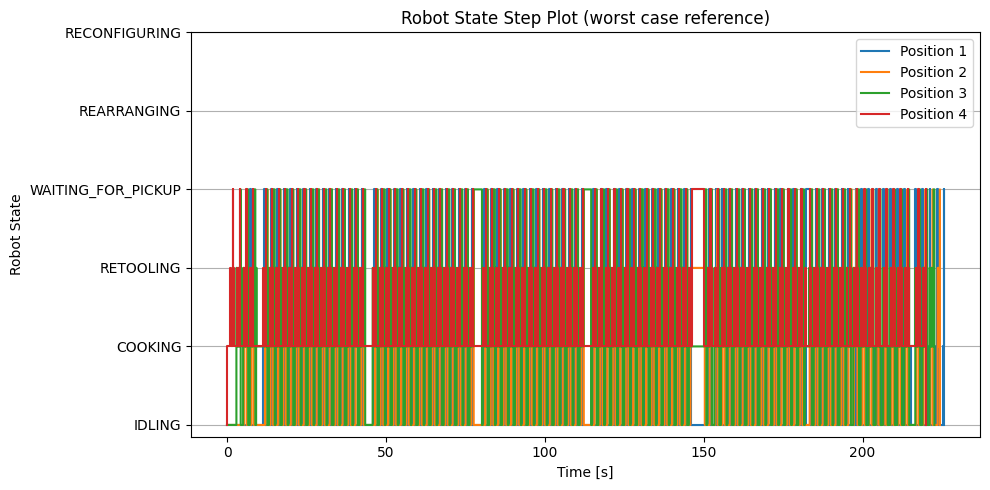

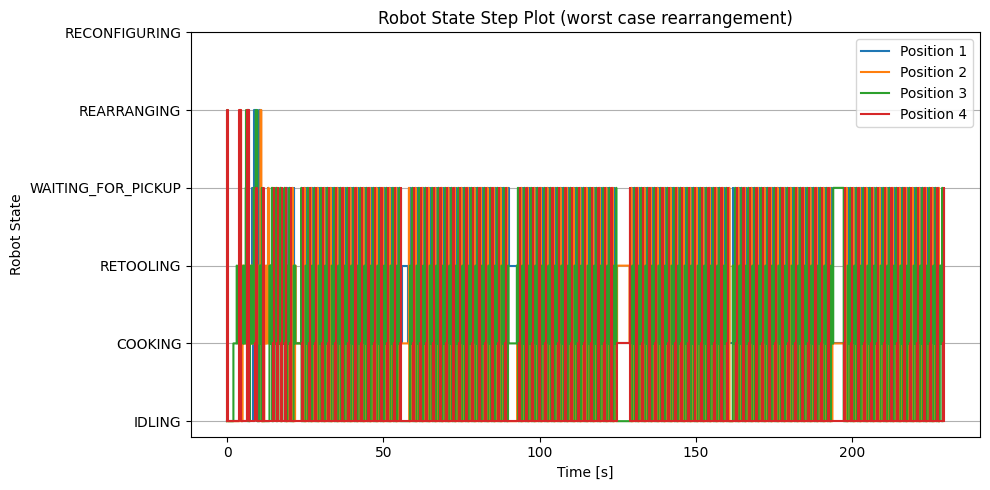

In [29]:
def plot_step_plot(statistics_df, title_addition):
    plt.figure(figsize=(10, 5))
    positions = sorted(statistics_df['Position'].unique().to_list())
    for pos in positions:
        pos_df = statistics_df.filter(pl.col('Position') == pos)
        plt.step(
            pos_df['Timestamp'].to_numpy() / 1e9,
            pos_df['State'].to_numpy(),
            where='post',
            label=f'Position {pos}'
        )

    # Map y-ticks to state names
    state_vals = sorted(ROBOT_STATE_NAME.keys())
    plt.yticks(state_vals, [ROBOT_STATE_NAME[v] for v in state_vals])

    plt.xlabel('Time [s]')
    plt.ylabel('Robot State')
    plt.title(f'Robot State Step Plot ({title_addition})')
    plt.grid(True, axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, (robot_df, completed_df, received_df) in loaded.items():
    label = experiments[name]["label"]
    # Get t0 reference timestamp from received order timestamps
    t0_reference = received_df.filter(pl.col("ReceivedOrdersCount") == 1)["Timestamp"][0]
    # Set t0 reference for robots
    robot_df = robot_df.with_columns(
        pl.when(pl.col("Timestamp") - t0_reference < 0)
        .then(0)
        .otherwise(pl.col("Timestamp") - t0_reference)
        .alias("Timestamp")
    )
    plot_step_plot(robot_df, label)